In [44]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import os

os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k.csv',
 'placement_dataset (1).csv',
 'placement_predict_50k_adjusted.csv',
 'placement_predict_50k_adjusted.gsheet',
 'age_insurance.csv',
 'indexData.csv']

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [47]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab/placement_predict_50k_adjusted.csv'
)

print(df.head())
print("\nDataset Shape:", df.shape)

   Gender       City CollegeTier      Stream Specialisation Hostel  \
0  Female      Delhi       Tier3          IT    DataScience    Yes   
1    Male    Chennai       Tier2         ECE             AI    Yes   
2  Female  Hyderabad       Tier3         ECE     Networking     No   
3  Female     Jaipur       Tier3         ECE       Embedded     No   
4    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  CGPA  AttendancePercent  Internships  ...  Workshops  \
0               Yes  6.63               68.3            2  ...        0.0   
1                No  6.40               71.0            1  ...        0.0   
2                No  7.73               75.1            1  ...        2.0   
3                No  9.73               99.2            4  ...        5.0   
4                No  9.01               99.6            2  ...        NaN   

   Certifications  Publications  AptitudeTestScore  SoftSkillsRating  \
0               1             0             

In [48]:
target_col = "CGPA"

sgpa_cols = [f"SGPA_Sem{i}" for i in range(1, 9)]

drop_cols = [
    c for c in [target_col, "StudentID", "CGPA_Tier"] + sgpa_cols
    if c in df.columns
]

feature_df = df.drop(
    columns=drop_cols
).select_dtypes(
    include=[np.number]
)

feature_df = feature_df.fillna(
    feature_df.median()
)

X = feature_df.values

y = df[target_col].values.reshape(-1, 1)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (50000, 12)
Target: (50000, 1)


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 40000
Testing samples: 10000


In [50]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

X_train_b = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_b = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]

print("Training shape:", X_train_b.shape)
print("Testing shape:", X_test_b.shape)

Training shape: (40000, 13)
Testing shape: (10000, 13)


In [51]:
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y

        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)

        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

In [52]:
theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)

Iteration    0 | Loss: 27.1394
Iteration  100 | Loss: 3.5957
Iteration  200 | Loss: 0.5039
Iteration  300 | Loss: 0.0894
Iteration  400 | Loss: 0.0338
Iteration  500 | Loss: 0.0263
Iteration  600 | Loss: 0.0252
Iteration  700 | Loss: 0.0251
Iteration  800 | Loss: 0.0250
Iteration  900 | Loss: 0.0250


In [53]:
y_pred = X_test_b @ theta

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nFinal weights:")
print(theta.ravel())

print(f"\nTest MSE: {mse:.4f}")
print(f"Test R^2: {r2:.4f}")


Final weights:
[ 7.29885264e+00  1.51572915e-01  6.19255015e-02  9.18994042e-02
  6.11528698e-02  9.21034270e-02  3.59116610e-02  1.42812012e-01
  1.53586067e-01  1.62139076e-01  1.37183398e-01  2.54455045e-02
 -3.15083847e-04]

Test MSE: 0.0502
Test R^2: 0.9508


In [54]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()

sk_model.fit(
    X_train,
    y_train
)

sk_pred = sk_model.predict(X_test)

print(
    f"sklearn LinearRegression R^2: "
    f"{r2_score(y_test, sk_pred):.4f}"
)

sklearn LinearRegression R^2: 0.9508


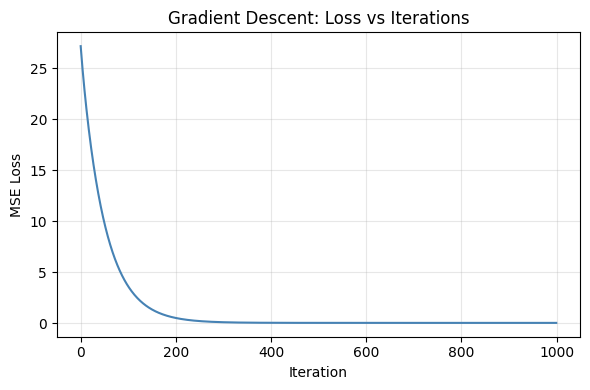

In [55]:
plt.figure(figsize=(6, 4))

plt.plot(
    range(len(losses)),
    losses,
    color="steelblue"
)

plt.title("Gradient Descent: Loss vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

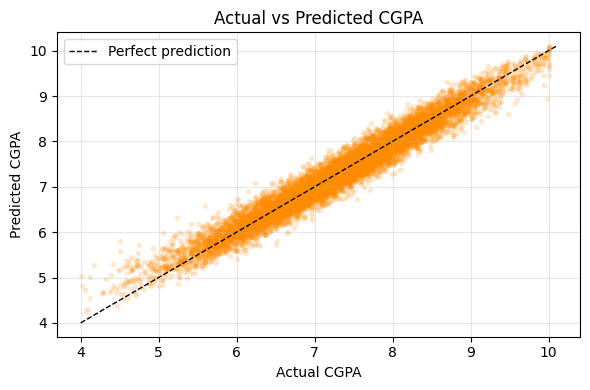

In [56]:
plt.figure(figsize=(6, 4))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.15,
    s=8,
    color="darkorange"
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    lims,
    lims,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)

plt.title("Actual vs Predicted CGPA")
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
plt.savefig(
    '/content/drive/MyDrive/Colab/gradient_descent_plots.png',
    dpi=150,
    bbox_inches='tight'
)

print("Saved to Google Drive → Colab → gradient_descent_plots.png")

Saved to Google Drive → Colab → gradient_descent_plots.png


<Figure size 640x480 with 0 Axes>